In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 01. EDA & Data Preparation

This notebook organizes the dataset, performs exploratory data analysis, checks data quality, and prepares train/validation CSV files.

본 노트북은 안저 이미지 데이터셋을 정리하고, EDA를 수행하며, 데이터 품질 확인 및 학습용 CSV 생성을 목표로 합니다.

## Notebook Structure

1. Environment & Path Setup  
2. Environment Record  
3. Dataset Indexing  
4. Dataset Statistics  
5. Dataset Distribution  
6. Sample Visualization  
7. Corrupted Image Check  
8. Image Resolution Analysis  
9. RGB Channel Analysis  
10. Leakage-aware Data Splitting  
11. Train / Validation CSV Export  
12. Final Summary

## 1. Environment & Path Setup

Set project paths and create output directories.

프로젝트 경로를 설정하고 결과 저장 폴더를 생성합니다.

In [3]:
import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -----------------------------
# Project paths
# -----------------------------
ROOT = Path("/content/drive/MyDrive/eye_disease_classifier")

DATA_ROOT = ROOT / "data" / "Augmented Dataset"
OUTPUT_DIR = ROOT / "outputs" / "eda"
FIGURE_DIR = ROOT / "figures" / "eda"
SPLIT_DIR = ROOT / "splits"

for d in [OUTPUT_DIR, FIGURE_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("ROOT:", ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("SPLIT_DIR:", SPLIT_DIR)
print("Data root exists:", DATA_ROOT.exists())

ROOT: /content/drive/MyDrive/eye_disease_classifier
DATA_ROOT: /content/drive/MyDrive/eye_disease_classifier/data/Augmented Dataset
OUTPUT_DIR: /content/drive/MyDrive/eye_disease_classifier/outputs/eda
FIGURE_DIR: /content/drive/MyDrive/eye_disease_classifier/figures/eda
SPLIT_DIR: /content/drive/MyDrive/eye_disease_classifier/splits
Data root exists: True


## 2. Environment Record

Record the runtime environment for reproducibility.

실험 재현성을 위해 실행 환경을 기록합니다.

In [4]:
import platform

try:
    import torch
    torch_version = torch.__version__
    cuda_available = torch.cuda.is_available()
    cuda_version = torch.version.cuda
    gpu_name = torch.cuda.get_device_name(0) if cuda_available else "CPU only"
except Exception as e:
    torch_version = "Not available"
    cuda_available = False
    cuda_version = "Not available"
    gpu_name = "Not available"

env_info = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "torch_version": torch_version,
    "cuda_available": cuda_available,
    "cuda_version": cuda_version,
    "gpu_name": gpu_name,
}

for k, v in env_info.items():
    print(f"{k}: {v}")

python_version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.6.122+-x86_64-with-glibc2.35
torch_version: 2.10.0+cu128
cuda_available: True
cuda_version: 12.8
gpu_name: Tesla T4


## 3. Dataset Indexing

Collect image file paths and create a dataframe.

이미지 경로를 수집하고 데이터프레임으로 정리합니다.

In [5]:
# Supported image extensions
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_names = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

print("Number of classes:", len(class_names))
print("Class names:")
for idx, cls in enumerate(class_names):
    print(f"{idx}: {cls}")

Number of classes: 10
Class names:
0: Central Serous Chorioretinopathy [Color Fundus]
1: Diabetic Retinopathy
2: Disc Edema
3: Glaucoma
4: Healthy
5: Macular Scar
6: Myopia
7: Pterygium
8: Retinal Detachment
9: Retinitis Pigmentosa


In [6]:
records = []

for cls in class_names:
    cls_dir = DATA_ROOT / cls
    for img_path in cls_dir.iterdir():
        if img_path.suffix.lower() in IMG_EXTS:
            records.append({
                "path": str(img_path),
                "filename": img_path.name,
                "class": cls,
                "label": class_to_idx[cls],
            })

df = pd.DataFrame(records)
df = df.sort_values(["class", "filename"]).reset_index(drop=True)

print("Total images indexed:", len(df))
display(df.head())

Total images indexed: 16242


,path,filename,class,label
0,/content/drive/MyDrive/eye_disease_classifier/...,CSCR1.jpg,Central Serous Chorioretinopathy [Color Fundus],0
1,/content/drive/MyDrive/eye_disease_classifier/...,CSCR10.jpg,Central Serous Chorioretinopathy [Color Fundus],0
2,/content/drive/MyDrive/eye_disease_classifier/...,CSCR100.jpg,Central Serous Chorioretinopathy [Color Fundus],0
3,/content/drive/MyDrive/eye_disease_classifier/...,CSCR101.jpg,Central Serous Chorioretinopathy [Color Fundus],0
4,/content/drive/MyDrive/eye_disease_classifier/...,CSCR102.jpg,Central Serous Chorioretinopathy [Color Fundus],0


In [7]:
data_index_path = OUTPUT_DIR / "data_index.csv"
df.to_csv(data_index_path, index=False)
print("Saved:", data_index_path)

Saved: /content/drive/MyDrive/eye_disease_classifier/outputs/eda/data_index.csv


## 4. Dataset Statistics

Check overall dataset size and class distribution.

데이터셋 전체 규모와 클래스별 데이터 수를 확인합니다.

In [8]:
class_counts = df["class"].value_counts().sort_index()
stats_df = class_counts.rename_axis("class").reset_index(name="num_images")
stats_df["ratio"] = stats_df["num_images"] / stats_df["num_images"].sum()

display(stats_df)

print("Total images:", len(df))
print("Number of classes:", df["class"].nunique())
print("Minimum class count:", stats_df["num_images"].min())
print("Maximum class count:", stats_df["num_images"].max())
print("Imbalance ratio (max/min):", round(stats_df["num_images"].max() / stats_df["num_images"].min(), 2))

,class,num_images,ratio
0,Central Serous Chorioretinopathy [Color Fundus],606,0.037311
1,Diabetic Retinopathy,3444,0.212043
2,Disc Edema,762,0.046915
3,Glaucoma,2880,0.177318
4,Healthy,2676,0.164758
5,Macular Scar,1937,0.119259
6,Myopia,2251,0.138591
7,Pterygium,102,0.006280
8,Retinal Detachment,750,0.046177
9,Retinitis Pigmentosa,834,0.051348


Total images: 16242
Number of classes: 10
Minimum class count: 102
Maximum class count: 3444
Imbalance ratio (max/min): 33.76


In [9]:
stats_path = OUTPUT_DIR / "class_statistics.csv"
stats_df.to_csv(stats_path, index=False)
print("Saved:", stats_path)

Saved: /content/drive/MyDrive/eye_disease_classifier/outputs/eda/class_statistics.csv


## 5. Dataset Distribution

Visualize class distribution and class imbalance in one figure.

클래스별 데이터 분포를 시각화하여 불균형 정도를 확인합니다.

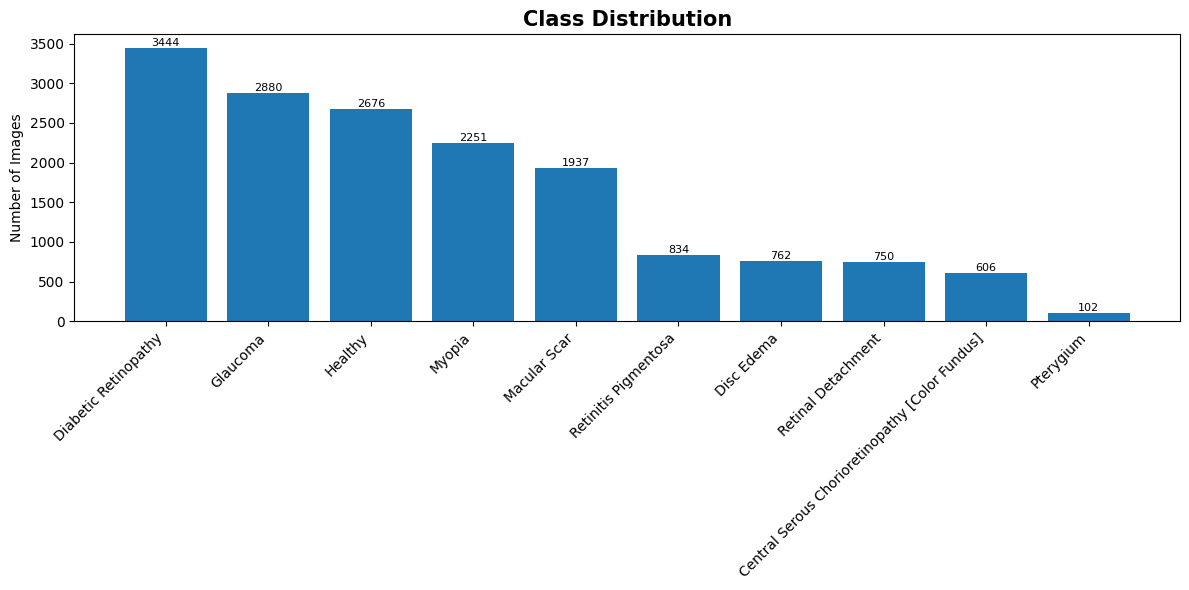

Saved: /content/drive/MyDrive/eye_disease_classifier/figures/eda/class_distribution.png


In [10]:
plot_df = stats_df.sort_values("num_images", ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(plot_df["class"], plot_df["num_images"])

plt.title("Class Distribution", fontsize=15, weight="bold")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

save_path = FIGURE_DIR / "class_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 6. Sample Visualization

Display representative sample images from each class.

각 클래스의 대표 이미지를 확인하여 데이터의 시각적 특성을 파악합니다.

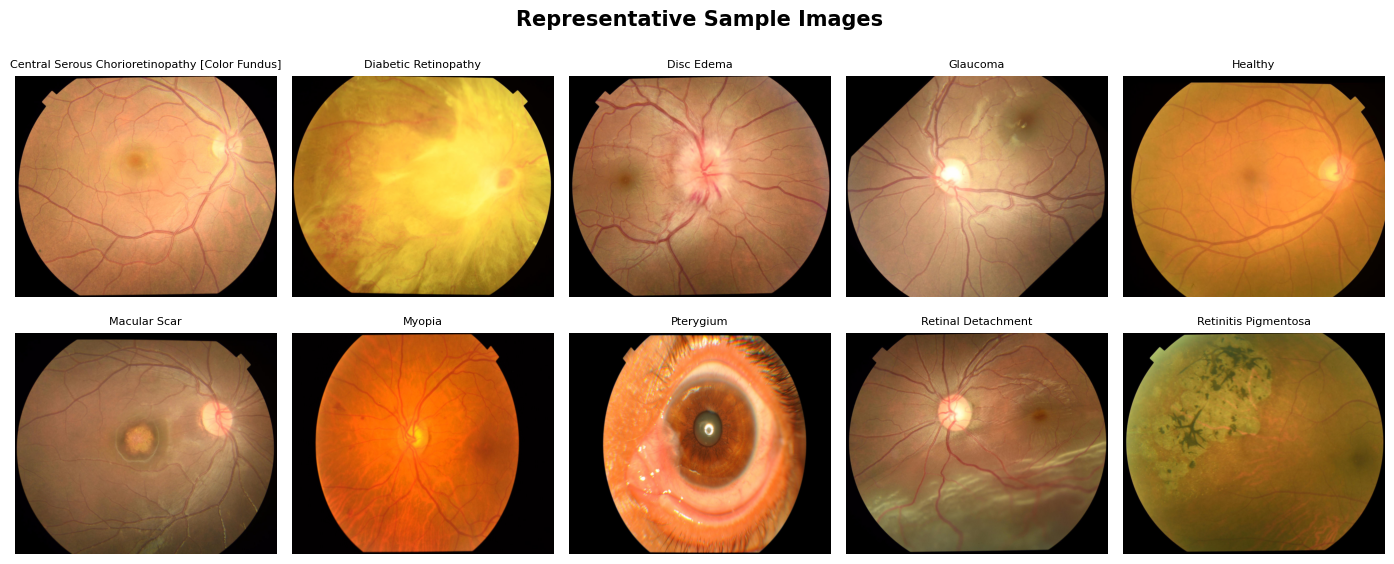

Saved: /content/drive/MyDrive/eye_disease_classifier/figures/eda/sample_images.png


In [11]:
sample_per_class = 1
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for ax, cls in zip(axes, class_names):
    sample_path = df[df["class"] == cls]["path"].iloc[0]
    img = Image.open(sample_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")

plt.suptitle("Representative Sample Images", fontsize=15, weight="bold")
plt.tight_layout()

save_path = FIGURE_DIR / "sample_images.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 7. Corrupted Image Check

Check whether image files can be opened successfully.

이미지 파일이 정상적으로 열리는지 확인합니다.

> Note: Checking all images can take a long time on Google Colab, especially when files are stored in Google Drive.  
> 기본 설정은 샘플 검사이며, 전체 검사가 필요하면 `CHECK_ALL_IMAGES = True`로 변경하세요.

In [12]:
# -----------------------------
# Corrupted image check setting
# -----------------------------
CHECK_ALL_IMAGES = False  # True로 변경하면 전체 이미지 검사
SAMPLE_SIZE = 1000        # CHECK_ALL_IMAGES=False일 때 검사할 이미지 수

if CHECK_ALL_IMAGES:
    check_df = df.copy()
else:
    check_df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=SEED).reset_index(drop=True)

print("Images to check:", len(check_df), "/", len(df))

Images to check: 1000 / 16242


In [13]:
from tqdm.auto import tqdm

bad_files = []

for path in tqdm(check_df["path"], desc="Checking images"):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        bad_files.append({
            "path": path,
            "error": str(e)
        })

bad_df = pd.DataFrame(bad_files)

print("Number of corrupted/unreadable files:", len(bad_df))
display(bad_df.head())

bad_path = OUTPUT_DIR / "corrupted_images.csv"
bad_df.to_csv(bad_path, index=False)
print("Saved:", bad_path)

Checking images:   0%|          | 0/1000 [00:00<?, ?it/s]

Number of corrupted/unreadable files: 0


""


Saved: /content/drive/MyDrive/eye_disease_classifier/outputs/eda/corrupted_images.csv


## 8. Image Resolution Analysis

Analyze image width and height distribution.

이미지 해상도 분포를 분석하여 입력 크기 설정에 참고합니다.

In [14]:
# For speed, use sampling. Set RESOLUTION_SAMPLE_SIZE = None to analyze all images.
RESOLUTION_SAMPLE_SIZE = 3000

if RESOLUTION_SAMPLE_SIZE is None:
    resolution_df = df.copy()
else:
    resolution_df = df.sample(n=min(RESOLUTION_SAMPLE_SIZE, len(df)), random_state=SEED).reset_index(drop=True)

widths, heights = [], []

for path in tqdm(resolution_df["path"], desc="Reading image sizes"):
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        widths.append(np.nan)
        heights.append(np.nan)

resolution_df["width"] = widths
resolution_df["height"] = heights

display(resolution_df[["class", "filename", "width", "height"]].head())

Reading image sizes:   0%|          | 0/3000 [00:00<?, ?it/s]

,class,filename,width,height
0,Healthy,Healthy1933.jpg,2004,1690
1,Myopia,Myopia1099.jpg,2004,1690
2,Diabetic Retinopathy,DR145.jpg,2004,1690
3,Glaucoma,Glaucoma944.jpg,2004,1690
4,Diabetic Retinopathy,DR2395.jpg,2004,1690


In [15]:
resolution_summary = resolution_df[["width", "height"]].describe()
display(resolution_summary)

resolution_path = OUTPUT_DIR / "resolution_analysis.csv"
resolution_df.to_csv(resolution_path, index=False)
print("Saved:", resolution_path)

,width,height
count,3000.0,3000.0
mean,2004.0,1690.0
std,0.0,0.0
min,2004.0,1690.0
25%,2004.0,1690.0
50%,2004.0,1690.0
75%,2004.0,1690.0
max,2004.0,1690.0


Saved: /content/drive/MyDrive/eye_disease_classifier/outputs/eda/resolution_analysis.csv


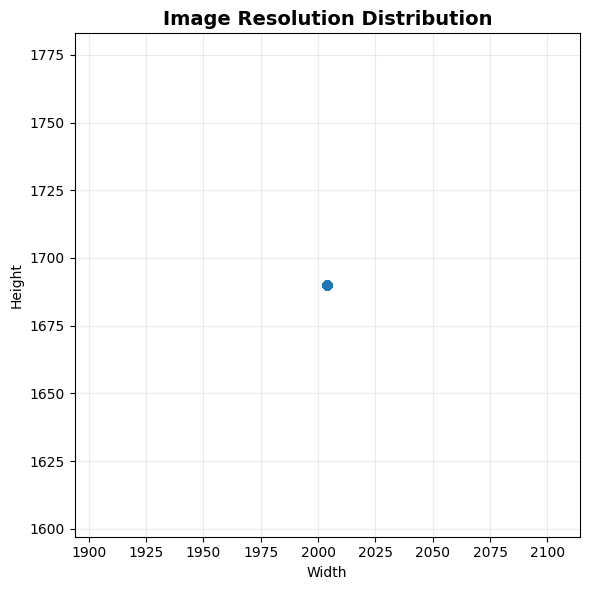

Saved: /content/drive/MyDrive/eye_disease_classifier/figures/eda/resolution_analysis.png


In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(resolution_df["width"], resolution_df["height"], alpha=0.25)

plt.title("Image Resolution Distribution", fontsize=14, weight="bold")
plt.xlabel("Width")
plt.ylabel("Height")
plt.grid(alpha=0.25)
plt.tight_layout()

save_path = FIGURE_DIR / "resolution_analysis.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 9. RGB Channel Analysis

Analyze RGB channel intensity distribution.

RGB 채널 분포를 분석하여 밝기 및 색상 편차를 확인합니다.

In [17]:
# For speed, use sampling.
RGB_SAMPLE_PER_CLASS = 100

rgb_records = []

for cls in tqdm(class_names, desc="Class"):
    cls_df = df[df["class"] == cls]
    sample_df = cls_df.sample(n=min(RGB_SAMPLE_PER_CLASS, len(cls_df)), random_state=SEED)

    for path in sample_df["path"]:
        try:
            img = Image.open(path).convert("RGB").resize((224, 224))
            arr = np.asarray(img).astype(np.float32)

            rgb_records.append({
                "class": cls,
                "r_mean": arr[:, :, 0].mean(),
                "g_mean": arr[:, :, 1].mean(),
                "b_mean": arr[:, :, 2].mean(),
            })
        except Exception:
            continue

rgb_df = pd.DataFrame(rgb_records)
display(rgb_df.head())

Class:   0%|          | 0/10 [00:00<?, ?it/s]

,class,r_mean,g_mean,b_mean
0,Central Serous Chorioretinopathy [Color Fundus],144.215561,107.488380,74.925705
1,Central Serous Chorioretinopathy [Color Fundus],133.443802,91.890526,59.928650
2,Central Serous Chorioretinopathy [Color Fundus],141.873810,95.476746,52.662468
3,Central Serous Chorioretinopathy [Color Fundus],128.941681,82.506775,45.350803
4,Central Serous Chorioretinopathy [Color Fundus],112.005936,55.842335,17.695412


In [18]:
rgb_summary = rgb_df.groupby("class")[["r_mean", "g_mean", "b_mean"]].mean().reset_index()
display(rgb_summary)

rgb_path = OUTPUT_DIR / "rgb_analysis.csv"
rgb_df.to_csv(rgb_path, index=False)
print("Saved:", rgb_path)

,class,r_mean,g_mean,b_mean
0,Central Serous Chorioretinopathy [Color Fundus],143.055405,88.099861,47.444656
1,Diabetic Retinopathy,141.830307,77.937775,28.033028
2,Disc Edema,128.488724,73.247818,34.607552
3,Glaucoma,138.936874,87.425636,48.078236
4,Healthy,146.075729,90.657951,48.285110
5,Macular Scar,143.628479,87.656555,45.842476
6,Myopia,138.339294,73.082748,37.184357
7,Pterygium,127.319199,75.651947,36.699287
8,Retinal Detachment,132.276276,80.156502,38.074448
9,Retinitis Pigmentosa,125.506180,85.846283,36.264526


Saved: /content/drive/MyDrive/eye_disease_classifier/outputs/eda/rgb_analysis.csv


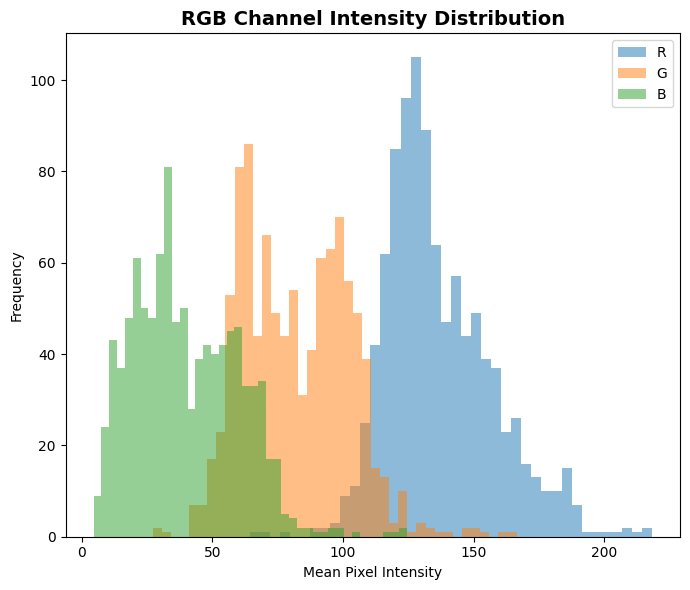

Saved: /content/drive/MyDrive/eye_disease_classifier/figures/eda/rgb_analysis.png


In [19]:
plt.figure(figsize=(7, 6))

plt.hist(rgb_df["r_mean"], bins=40, alpha=0.5, label="R")
plt.hist(rgb_df["g_mean"], bins=40, alpha=0.5, label="G")
plt.hist(rgb_df["b_mean"], bins=40, alpha=0.5, label="B")

plt.title("RGB Channel Intensity Distribution", fontsize=14, weight="bold")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

save_path = FIGURE_DIR / "rgb_analysis.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 10. Leakage-aware Data Splitting

The dataset includes augmented images, but explicit metadata linking augmented images to their original source images is not provided.

Therefore, exact augmentation lineage tracking is not possible.  
Instead, this notebook applies a best-effort leakage-aware splitting strategy based on available filename and class information.

데이터셋에는 증강 이미지와 원본 이미지 간의 명시적인 연결 정보가 제공되지 않습니다.  
따라서 증강 계보를 완벽하게 추적하는 것은 불가능하며, 파일명과 클래스 정보를 기반으로 가능한 범위에서 데이터 누수를 완화하는 split 전략을 적용합니다.

In [20]:
import re

def make_group_id(filename):
    '''
    Best-effort group ID extraction.

    If filenames contain structured numbering, this function can be adjusted.
    Current default:
    - remove file extension
    - remove common augmentation suffix-like patterns if present
    - otherwise use filename stem as group id
    '''
    stem = Path(filename).stem

    # Common augmentation suffix patterns (adjust if your dataset has specific naming rules)
    stem = re.sub(r"(_rotated|_rotate|_flip|_flipped|_zoom|_shift|_aug|_augmentation).*", "", stem, flags=re.IGNORECASE)
    stem = re.sub(r"(_\d+)$", r"\1", stem)

    return stem

df["group_id"] = df["class"] + "__" + df["filename"].apply(make_group_id)

print("Number of unique group IDs:", df["group_id"].nunique())
display(df[["filename", "class", "group_id"]].head())

Number of unique group IDs: 16242


,filename,class,group_id
0,CSCR1.jpg,Central Serous Chorioretinopathy [Color Fundus],Central Serous Chorioretinopathy [Color Fundus...
1,CSCR10.jpg,Central Serous Chorioretinopathy [Color Fundus],Central Serous Chorioretinopathy [Color Fundus...
2,CSCR100.jpg,Central Serous Chorioretinopathy [Color Fundus],Central Serous Chorioretinopathy [Color Fundus...
3,CSCR101.jpg,Central Serous Chorioretinopathy [Color Fundus],Central Serous Chorioretinopathy [Color Fundus...
4,CSCR102.jpg,Central Serous Chorioretinopathy [Color Fundus],Central Serous Chorioretinopathy [Color Fundus...


,group_size
count,16242.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


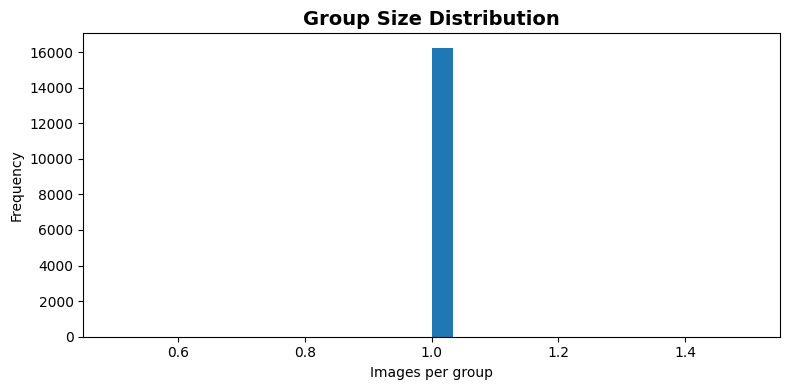

Saved: /content/drive/MyDrive/eye_disease_classifier/figures/eda/group_size_distribution.png


In [21]:
# Check group size distribution
group_size = df.groupby("group_id").size().reset_index(name="group_size")

display(group_size["group_size"].describe())

plt.figure(figsize=(8, 4))
plt.hist(group_size["group_size"], bins=30)
plt.title("Group Size Distribution", fontsize=14, weight="bold")
plt.xlabel("Images per group")
plt.ylabel("Frequency")
plt.tight_layout()

save_path = FIGURE_DIR / "group_size_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [22]:
from sklearn.model_selection import GroupShuffleSplit

VAL_SIZE = 0.2

gss = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)

train_idx, val_idx = next(gss.split(df, groups=df["group_id"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

# Verify group leakage
train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
overlap = train_groups.intersection(val_groups)

print("Overlapping groups:", len(overlap))
assert len(overlap) == 0, "Group leakage detected!"

Train size: 12993
Validation size: 3249
Overlapping groups: 0


In [23]:
split_summary = pd.DataFrame({
    "train": train_df["class"].value_counts().sort_index(),
    "val": val_df["class"].value_counts().sort_index()
}).fillna(0).astype(int)

split_summary["train_ratio"] = split_summary["train"] / split_summary["train"].sum()
split_summary["val_ratio"] = split_summary["val"] / split_summary["val"].sum()

display(split_summary)

,train,val,train_ratio,val_ratio
class,,,,
Central Serous Chorioretinopathy [Color Fundus],474,132,0.036481,0.040628
Diabetic Retinopathy,2785,659,0.214346,0.202832
Disc Edema,599,163,0.046102,0.050169
Glaucoma,2318,562,0.178404,0.172976
Healthy,2098,578,0.161472,0.177901
Macular Scar,1541,396,0.118602,0.121884
Myopia,1823,428,0.140306,0.131733
Pterygium,88,14,0.006773,0.004309
Retinal Detachment,600,150,0.046179,0.046168


## 11. Train / Validation CSV Export

Save split results for model training.

모델 학습에 사용할 train/validation CSV 파일을 저장합니다.

In [24]:
train_csv_path = SPLIT_DIR / "train.csv"
val_csv_path = SPLIT_DIR / "val.csv"

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)

print("Saved:", train_csv_path)
print("Saved:", val_csv_path)

Saved: /content/drive/MyDrive/eye_disease_classifier/splits/train.csv
Saved: /content/drive/MyDrive/eye_disease_classifier/splits/val.csv


## 12. Final Summary

### Key Findings

- The dataset contains **10 retinal disease classes**.
- Severe class imbalance exists across disease categories.
- Image resolution and RGB distributions vary across samples.
- The dataset includes augmented images, but explicit augmentation metadata is not available.
- A leakage-aware group split was applied as a best-effort strategy to reduce potential data leakage.

### 핵심 요약

- 총 10개 안저 질환 클래스로 구성된 데이터셋입니다.
- 클래스 간 데이터 불균형이 존재합니다.
- 이미지 해상도와 RGB 분포에서 편차가 확인됩니다.
- 증강 이미지가 포함되어 있으나 원본-증강 관계 metadata는 제공되지 않습니다.
- 잠재적인 데이터 누수를 줄이기 위해 leakage-aware group split을 적용했습니다.